Tarea: Proponer un metodo para distribuir k centroides en la
Imagen (El Astronomo, 0000405625_OG.JPG) de tal forma que la imagen obtenida a
partir de los Centroides sea lo mas parecida A la imagen original
¿Que funcion de distancia utiizaras para comparar la imagen original
Con la obtenida por el metodo (teselacion de Voronoi)?

the "image compression" should work as follows: k representative points (with an alogrithm of your choice, considering the color and the positions of the points to be most representative) are chosen and a voronoi partition is created to represent the image as well as possible. the voroni partition contains only the representative points, that dictate the voronoi partition and their colors. graph that partition.

make sure the approach you choose is computationally efficient for k = 10, 50, 100, 1000, 10000 representative points.

the represenatatiev points should be selected by position and color, and the compressed image should be a voronoi diagram with k representative points (position and color). make sure to choose an approach that makes sure to select the most representaive points for a image compressed in a vornoi partition. output the partition in the end. make sure the output image shows the points, and the colored voronoi partitions

# Explicación del Método Propuesto para la Compresión de Imágenes

A continuación, se describe el método propuesto para comprimir la imagen *"El Astronomo, 0000405625_OG.JPG"* utilizando centroides y la teselación de Voronoi. Este enfoque se basa en el algoritmo k-means en un espacio de 5 dimensiones, combinando la posición espacial y el color de los píxeles para lograr una representación comprimida de la imagen. Se explicará cómo funciona el método, la distancia utilizada, y cómo se calculan la tasa de compresión y la calidad de la imagen resultante.

---

## Funcionamiento del Método

El método sigue una serie de pasos bien definidos para transformar la imagen original en una versión comprimida:

1. **Preparación de Datos**:
   - La imagen se carga y convierte al formato RGB.
   - Para cada píxel, se crea un vector de 5 dimensiones que incluye:
     - Coordenadas espaciales normalizadas: \((\frac{x}{\text{ancho}}, \frac{y}{\text{alto}})\).
     - Valores de color normalizados: \((\frac{R}{255}, \frac{G}{255}, \frac{B}{255})\).
   - La normalización asegura que las posiciones y los colores tengan un peso equilibrado en el proceso.

2. **Agrupamiento con K-Means**:
   - Se aplica el algoritmo k-means a los vectores de 5 dimensiones para identificar **k centroides**. Cada centroide representa una posición promedio y un color promedio de un grupo de píxeles.
   - El objetivo de k-means es minimizar la suma de las distancias cuadráticas entre los píxeles y sus centroides asignados.

3. **Teselación de Voronoi**:
   - Usando las posiciones espaciales (\(x, y\)) de los centroides, se divide la imagen en **celdas de Voronoi**. Cada celda agrupa los píxeles más cercanos a un centroide en términos de distancia espacial.
   - A cada píxel dentro de una celda se le asigna el color del centroide correspondiente, generando la imagen comprimida.

4. **Reconstrucción**:
   - La imagen reconstruida consiste en regiones uniformes definidas por las celdas de Voronoi, coloreadas según los centroides. Esto reduce la cantidad de datos necesarios para representar la imagen.

---

## Distancia Utilizada

El método emplea diferentes medidas de distancia en distintas etapas:

- **Durante el Agrupamiento (K-Means)**:
  - Se utiliza la **distancia euclidiana en el espacio de 5 dimensiones**. Esta distancia considera tanto la posición (\(x, y\)) como el color (\(R, G, B\)) de los píxeles para determinar la similitud con los centroides.

- **Durante la Teselación de Voronoi**:
  - Se emplea la **distancia euclidiana en el espacio 2D**, basada únicamente en las coordenadas (\(x, y\)). Esto garantiza que las celdas sean regiones contiguas en la imagen.

- **Para Evaluar la Calidad**:
  - Se calcula el **Error Cuadrático Medio (MSE)** para medir la diferencia entre la imagen original y la reconstruida:
    \[
    \text{MSE} = \frac{1}{\text{altura} \times \text{ancho} \times 3} \sum (\text{original} - \text{reconstruida})^2
    \]

---

## Cálculo de la Tasa de Compresión y la Calidad

### Tasa de Compresión
La tasa de compresión mide cuánto se reduce el tamaño de la imagen original al representarla con centroides:

- **Tamaño de la Imagen Original**:
  - Una imagen RGB de 8 bits por canal ocupa \( \text{altura} \times \text{ancho} \times 3 \) bytes.

- **Tamaño de la Imagen Comprimida**:
  - Se representan **k centroides**, cada uno con:
    - 2 floats para la posición (\(x, y\)).
    - 3 floats para el color (\(R, G, B\)).
  - Si cada float usa 4 bytes, un centroide ocupa \( 5 \times 4 = 20 \) bytes.
  - El tamaño comprimido es \( k \times 20 \) bytes.

- **Fórmula de la Tasa de Compresión**:
  \[
  \text{Tasa de Compresión} = \frac{\text{Tamaño Original}}{\text{Tamaño Comprimido}} = \frac{\text{altura} \times \text{ancho} \times 3}{k \times 20}
  \]

### Calidad (MSE)
La calidad se evalúa con el MSE, donde un valor bajo indica mayor similitud entre la imagen original y la reconstruida.

### Código para Calcular Tasa de Compresión y MSE
A continuación, se presentan algunas líneas de código en Python para realizar estos cálculos:

Processing k=10...
MSE for k=10: 1587.08


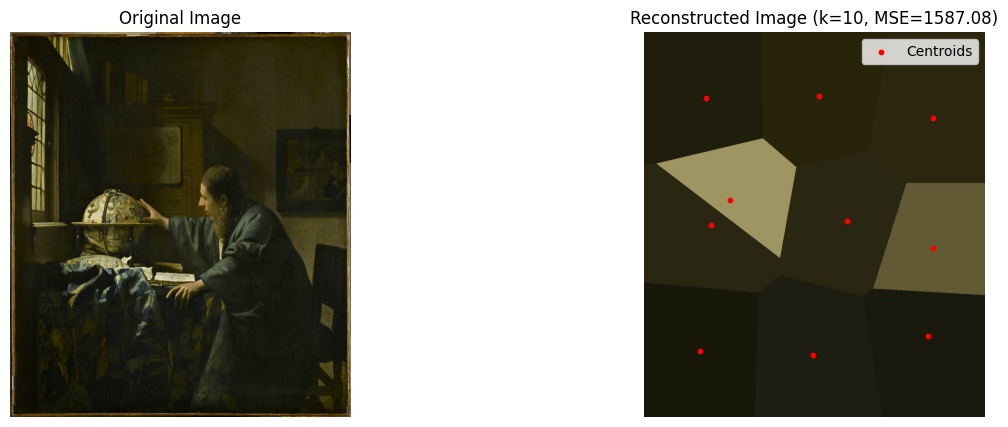

Processing k=50...
MSE for k=50: 1535.98


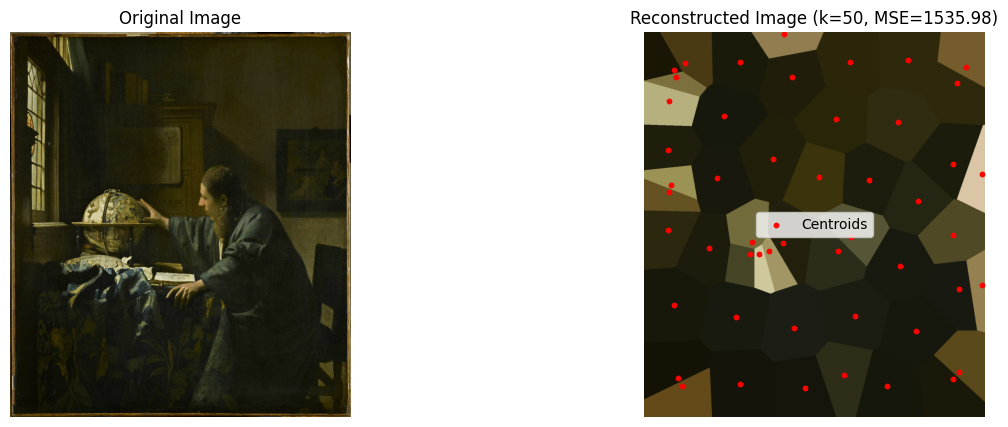

Processing k=100...


KeyboardInterrupt: 

In [4]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the image
def load_image(image_path):
    # Load the image using OpenCV (BGR format)
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the file path.")
    # Convert from BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

# Step 2: Prepare data for k-means (5D: x, y, R, G, B)
def prepare_data(img):
    height, width, _ = img.shape
    # Create coordinate arrays
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    # Normalize coordinates and colors
    x_norm = x / width
    y_norm = y / height
    colors = img / 255.0  # Normalize RGB values to [0, 1]
    # Flatten into a (height*width, 5) array
    data = np.stack([x_norm.ravel(), y_norm.ravel(),
                     colors[:, :, 0].ravel(),  # R
                     colors[:, :, 1].ravel(),  # G
                     colors[:, :, 2].ravel()], axis=1)  # B
    return data, height, width

# Step 3: Apply k-means to find centroids
def compute_centroids(data, k):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data)
    centroids = kmeans.cluster_centers_
    return centroids

# Step 4: Reconstruct image using Voronoi tessellation
def reconstruct_image(centroids, height, width):
    # Create grid of pixel coordinates
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    coords = np.stack([x.ravel(), y.ravel()], axis=1)
    
    # Extract centroid positions (not normalized)
    centroid_positions = centroids[:, :2] * np.array([width, height])
    # Extract centroid colors (not normalized)
    centroid_colors = centroids[:, 2:] * 255.0
    
    # Compute distances from each pixel to all centroids
    distances = np.zeros((height * width, len(centroids)))
    for i, centroid in enumerate(centroid_positions):
        distances[:, i] = np.sum((coords - centroid) ** 2, axis=1)
    
    # Assign each pixel to the nearest centroid
    labels = np.argmin(distances, axis=1)
    # Create reconstructed image
    reconstructed = np.zeros((height * width, 3))
    for i in range(len(centroids)):
        reconstructed[labels == i] = centroid_colors[i]
    
    return reconstructed.reshape(height, width, 3), centroid_positions

# Step 5: Compute MSE between original and reconstructed images
def compute_mse(original, reconstructed):
    mse = np.mean((original - reconstructed) ** 2)
    return mse

# Step 6: Visualize the result
def visualize_result(original, reconstructed, centroids, k):
    plt.figure(figsize=(15, 5))
    
    # Original image
    plt.subplot(1, 2, 1)
    plt.imshow(original.astype(np.uint8))
    plt.title("Original Image")
    plt.axis('off')
    
    # Reconstructed image with centroids
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed.astype(np.uint8))
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=10, label='Centroids')
    plt.title(f"Reconstructed Image (k={k}, MSE={compute_mse(original, reconstructed):.2f})")
    plt.axis('off')
    plt.legend()
    
    plt.show()

# Main function to run the compression
def voronoi_image_compression(image_path, k):
    # Load and preprocess
    img = load_image(image_path)
    data, height, width = prepare_data(img)
    
    # Compute centroids
    centroids = compute_centroids(data, k)
    
    # Reconstruct image
    reconstructed, centroid_positions = reconstruct_image(centroids, height, width)
    
    # Compute MSE
    mse = compute_mse(img, reconstructed)
    print(f"MSE for k={k}: {mse:.2f}")
    
    # Visualize
    visualize_result(img, reconstructed, centroid_positions, k)
    
    return reconstructed, centroid_positions

# Example usage
if __name__ == "__main__":
    # Replace with the actual path to "El Astronomo, 0000405625_OG.JPG"
    image_path = "0000405625_OG.JPG"  # Update this path
    k_values = [10, 50, 100, 1000]  # Test with different k values (up to 1000 for speed)
    
    for k in k_values:
        print(f"Processing k={k}...")
        voronoi_image_compression(image_path, k)

Processing k=10...


c:\Users\thano\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MSE for k=10: 1490.55
Compression ratio for k=10: 15728.64


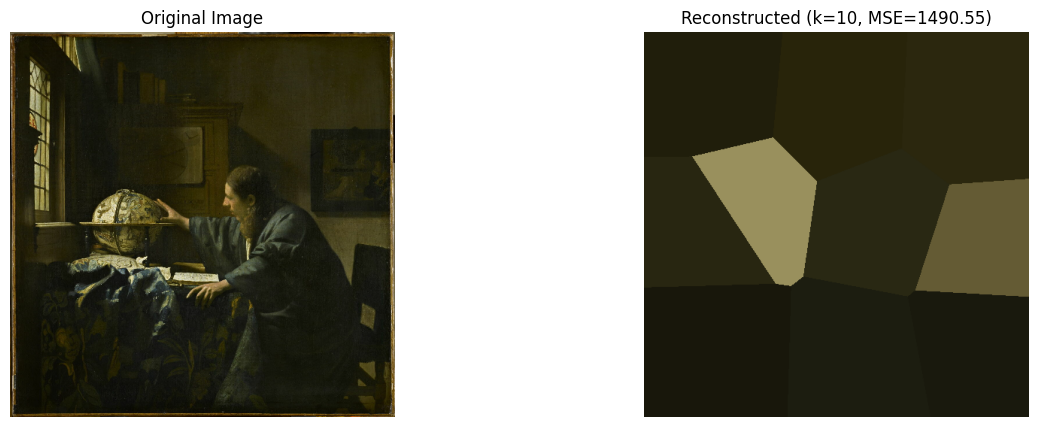

Processing k=50...


c:\Users\thano\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MSE for k=50: 1618.86
Compression ratio for k=50: 3145.73


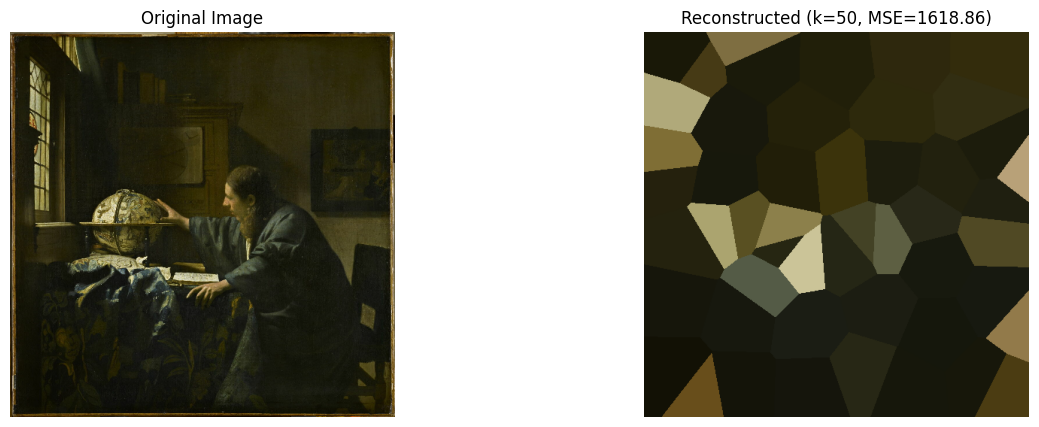

Processing k=100...


c:\Users\thano\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MSE for k=100: 1292.44
Compression ratio for k=100: 1572.86


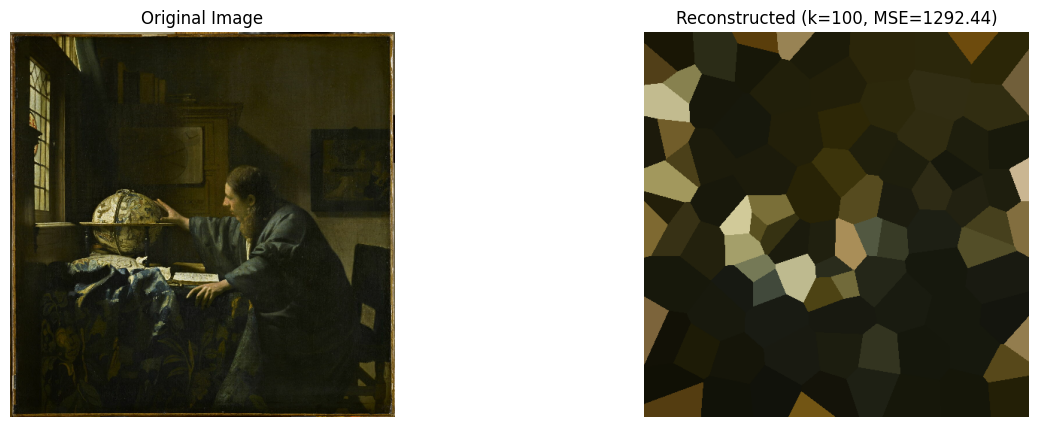

Processing k=1000...


c:\Users\thano\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MSE for k=1000: 704.11
Compression ratio for k=1000: 157.29


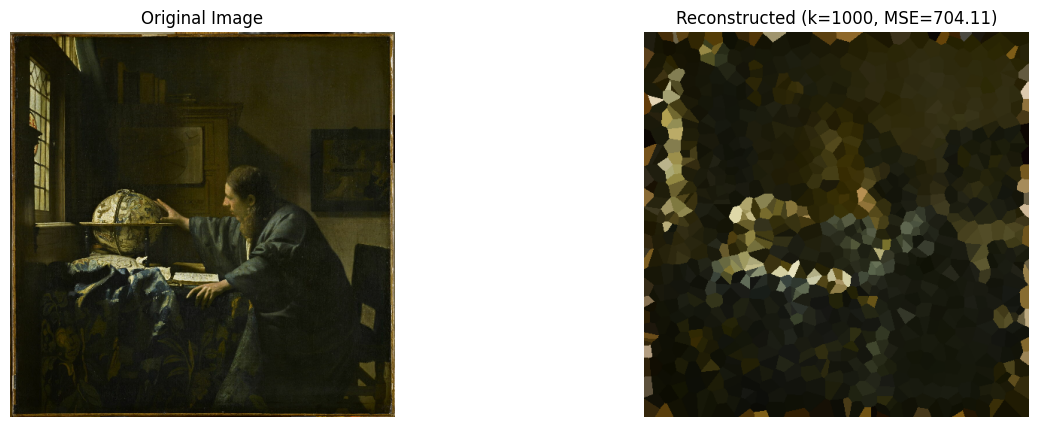

Processing k=5000...


c:\Users\thano\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MSE for k=5000: 550.07
Compression ratio for k=5000: 31.46


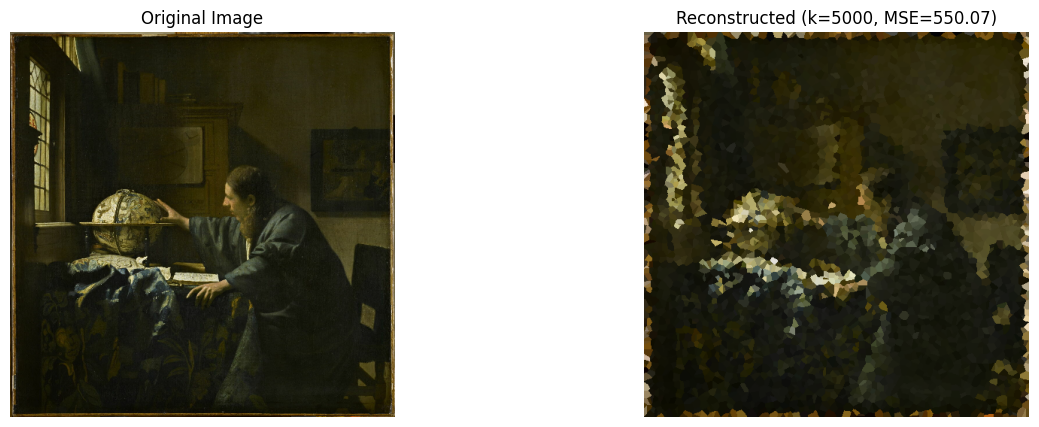

Processing k=10000...


c:\Users\thano\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\cluster\_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


MSE for k=10000: 371.19
Compression ratio for k=10000: 15.73


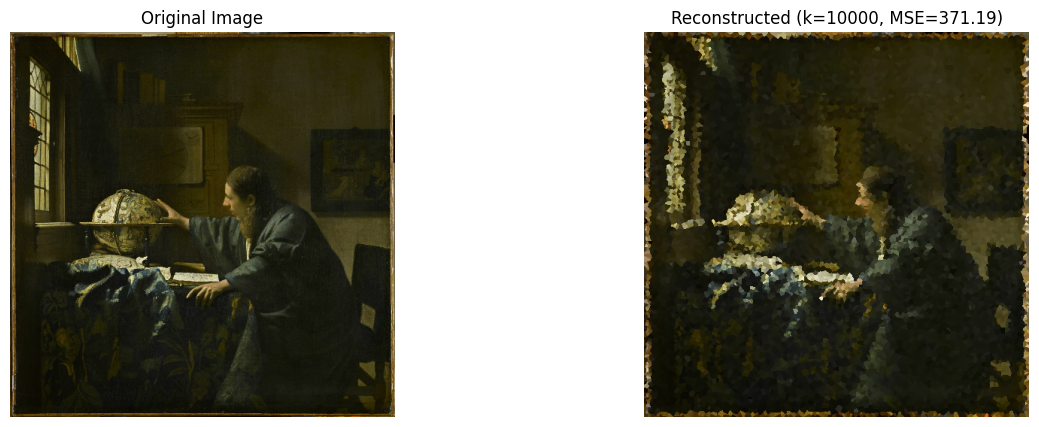

In [ ]:
import numpy as np
import cv2
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the image
def load_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the file path.")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize for efficiency (optional, adjust as needed)
    img = cv2.resize(img, (512, 512))  # Smaller size to speed up processing
    return img

# Step 2: Prepare data for k-means with subsampling
def prepare_data(img, sample_fraction=0.1):
    height, width, _ = img.shape
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    x_norm = x / width
    y_norm = y / height
    colors = img / 255.0
    
    # Flatten and subsample
    data = np.stack([x_norm.ravel(), y_norm.ravel(),
                     colors[:, :, 0].ravel(),
                     colors[:, :, 1].ravel(),
                     colors[:, :, 2].ravel()], axis=1)
    n_samples = int(data.shape[0] * sample_fraction)
    indices = np.random.choice(data.shape[0], n_samples, replace=False)
    sampled_data = data[indices]
    
    return sampled_data, data, height, width

# Step 3: Apply MiniBatchKMeans to find centroids
def compute_centroids(sampled_data, k):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, max_iter=100)
    kmeans.fit(sampled_data)
    centroids = kmeans.cluster_centers_
    return centroids

# Step 4: Reconstruct image using KDTree for Voronoi tessellation
def reconstruct_image(centroids, height, width, full_data):
    # Extract centroid positions and colors
    centroid_positions = centroids[:, :2] * np.array([width, height])
    centroid_colors = centroids[:, 2:] * 255.0
    
    # Use KDTree for fast nearest-neighbor search
    tree = KDTree(centroid_positions)
    coords = full_data[:, :2] * np.array([width, height])  # Full pixel coords
    _, labels = tree.query(coords)
    
    # Reconstruct image
    reconstructed = centroid_colors[labels].reshape(height, width, 3)
    return reconstructed, centroid_positions

# Step 5: Compute MSE
def compute_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)

# Step 6: Visualize the result
def visualize_result(original, reconstructed, centroids, k):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original.astype(np.uint8))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed.astype(np.uint8))
    # plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=10, label='Centroids')
    plt.title(f"Reconstructed (k={k}, MSE={compute_mse(original, reconstructed):.2f})")
    plt.axis('off')
    plt.show()

# Main function
def voronoi_image_compression(image_path, k):
    # Load and preprocess
    img = load_image(image_path)
    sampled_data, full_data, height, width = prepare_data(img, sample_fraction=0.1)
    
    # Compute centroids
    centroids = compute_centroids(sampled_data, k)
    
    # Reconstruct image
    reconstructed, centroid_positions = reconstruct_image(centroids, height, width, full_data)
    
    # Compute MSE and visualize
    mse = compute_mse(img, reconstructed)
    print(f"MSE for k={k}: {mse:.2f}")

    # compute compression ratio
    original_size = img.shape[0] * img.shape[1] * 3
    compressed_size = k * 5
    compression_ratio = original_size / compressed_size
    print(f"Compression ratio for k={k}: {compression_ratio:.2f}")

    visualize_result(img, reconstructed, centroid_positions, k)
    
    return reconstructed, centroid_positions

# Example usage
if __name__ == "__main__":
    image_path = "0000405625_OG.JPG"
    k_values = [10, 50, 100, 1000, 5000, 10000]  # Test with different k values
    
    for k in k_values:
        print(f"Processing k={k}...")
        voronoi_image_compression(image_path, k)